In [1]:
import pandas as pd


In [2]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:

CSV_PATH = '/content/drive/MyDrive/Colab Notebooks/music genre classification /features.csv'


In [4]:

try:
  features_df = pd.read_csv(CSV_PATH)
  print("Data frame loaded successfully !!")

  print("\nFirst 5 rows of the data set :\n")
  print(features_df.head())
  print("----------------------------------------------------")
  print(features_df.info())
  print("----------------------------------------------------")
  print(features_df.describe())
except FileNotFoundError:
  print(f"Error: The file at '{CSV_PATH}' was not found.")
  print("Please ensure the path is correct and the file exists in your mounted Google Drive.")
except Exception as e:
  print(f"An unexpected error occurred: {e}")

Data frame loaded successfully !!

First 5 rows of the data set :

    feature_0   feature_1  feature_2  feature_3  feature_4  feature_5  \
0 -163.668625  158.631943 -16.536753  41.775097   1.175720  21.389839   
1 -183.939590  149.700607  -0.209714  41.808208   1.313271  19.910112   
2 -184.146973  149.362045  -1.516809  40.959557  -0.194445  16.910528   
3 -153.885284  146.706253 -17.113646  42.922462   2.408136  24.651440   
4 -121.163399  144.575027  -0.785786  35.076187   0.177450  19.384785   

   feature_6  feature_7  feature_8  feature_9  ...  feature_19  feature_20  \
0 -11.084845  15.316117  -6.003472   3.131412  ...    0.536663    0.282330   
1 -11.864000  16.889139 -16.094011  10.564571  ...    0.352041    0.314522   
2 -14.380514  19.191526 -15.406534  10.468743  ...    0.273873    0.180940   
3 -18.947086  16.658485 -11.105832   6.346932  ...    0.286953    0.359205   
4 -12.973270  19.238920 -16.374735  11.666169  ...    0.226860    0.167164   

   feature_21  feature_22

In [5]:
print("\nMissing values check :\n")
print(features_df.isnull())
print("----------------------------------------------------------------------------------------------------")
print("\nMissing values count :\n")
features_df.isnull().sum()



Missing values check :

      feature_0  feature_1  feature_2  feature_3  feature_4  feature_5  \
0         False      False      False      False      False      False   
1         False      False      False      False      False      False   
2         False      False      False      False      False      False   
3         False      False      False      False      False      False   
4         False      False      False      False      False      False   
...         ...        ...        ...        ...        ...        ...   
9985      False      False      False      False      False      False   
9986      False      False      False      False      False      False   
9987      False      False      False      False      False      False   
9988      False      False      False      False      False      False   
9989      False      False      False      False      False      False   

      feature_6  feature_7  feature_8  feature_9  ...  feature_19  feature_20  \
0    

,0
feature_0,0
feature_1,0
feature_2,0
feature_3,0
feature_4,0
feature_5,0
feature_6,0
feature_7,0
feature_8,0
feature_9,0


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
genre_names = [
        'blues', 'classical', 'country', 'disco', 'hiphop',
        'jazz', 'metal', 'pop', 'reggae', 'rock'
    ]

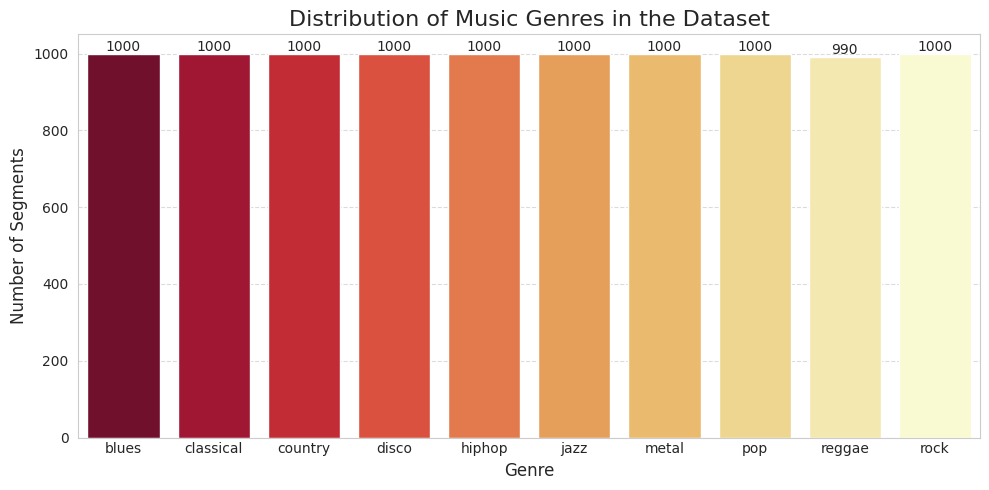

In [8]:
sns.set_style("whitegrid")
plt.figure(figsize=(10, 5))

    # Create the count plot
ax = sns.countplot(x='label', data=features_df, hue='label', palette='YlOrRd_r', legend=False)

    # Set the plot title and labels
ax.set_title('Distribution of Music Genres in the Dataset', fontsize=16)
ax.set_xlabel('Genre', fontsize=12)
ax.set_ylabel('Number of Segments', fontsize=12)

    # Set the x-axis tick labels to be the actual genre names
    # We rotate them slightly for better readability if they overlap
ax.set_xticks(range(len(genre_names))) # Set tick locations
ax.set_xticklabels(genre_names, rotation=0)
ax.tick_params(axis='x', direction='in') # Make tick marks point inwards

plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add data labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

    # Display the plot
plt.tight_layout()
plt.show()


 Generating box plot for spectral centroid: 



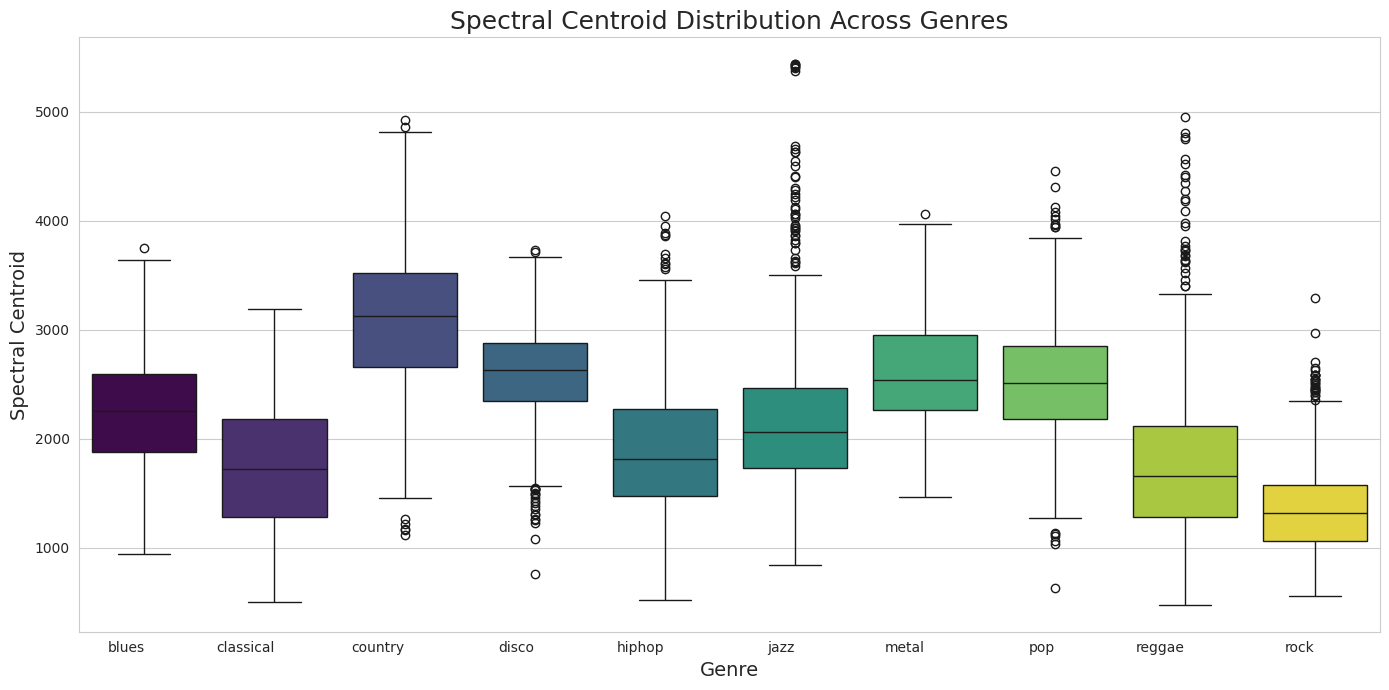

In [9]:
print("\n Generating box plot for spectral centroid: \n")
plt.figure(figsize=(14,7))
box = sns.boxplot(x='label', y='feature_25', data = features_df, palette = 'viridis', hue='label', legend=False)
box.set_title('Spectral Centroid Distribution Across Genres', fontsize=18)
box.set_xlabel('Genre', fontsize=14)
box.set_ylabel('Spectral Centroid', fontsize=14)
box.set_xticks(range(len(genre_names))) # Explicitly set tick locations
box.set_xticklabels(genre_names, rotation=0, ha="right")
plt.tight_layout()
plt.show()


 Generating box plot for feature_0: 



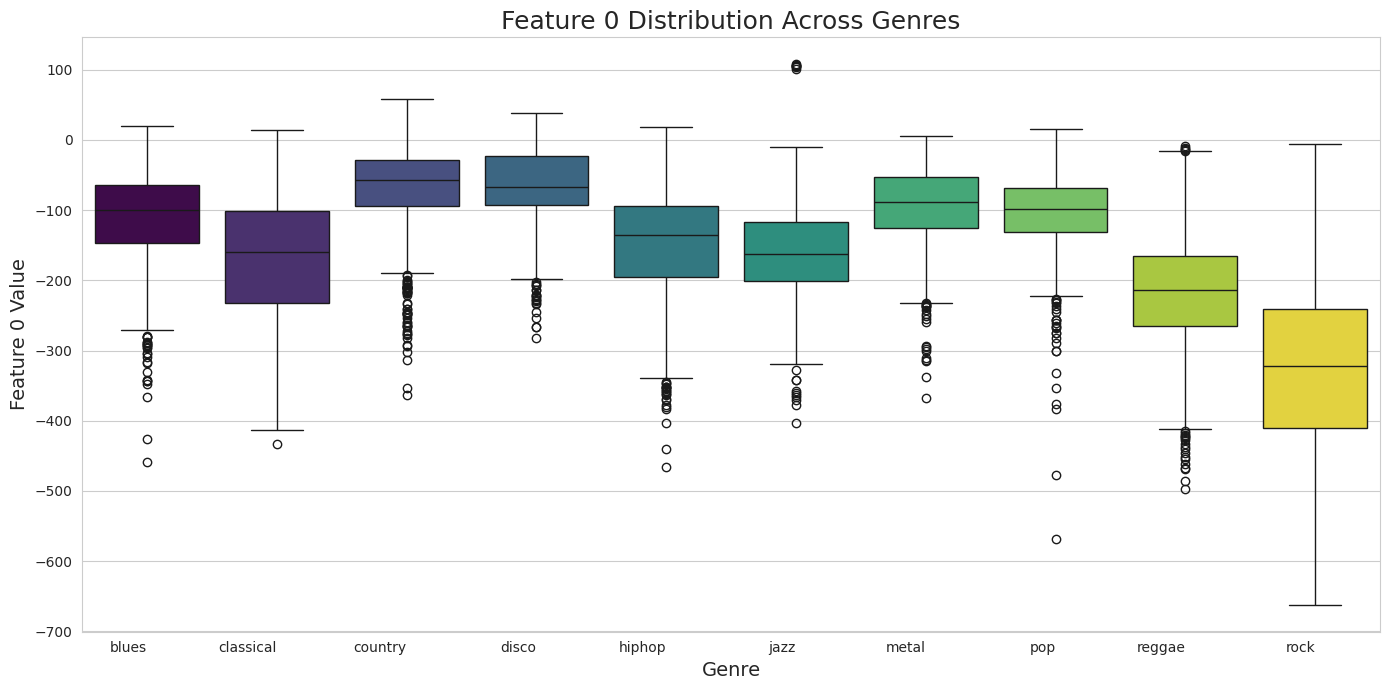

In [10]:
print("\n Generating box plot for feature_0: \n")
plt.figure(figsize=(14,7))
box = sns.boxplot(x='label', y='feature_0', data = features_df, palette = 'viridis', hue='label', legend=False)
box.set_title('Feature 0 Distribution Across Genres', fontsize=18)
box.set_xlabel('Genre', fontsize=14)
box.set_ylabel('Feature 0 Value', fontsize=14)
box.set_xticks(range(len(genre_names))) # Explicitly set tick locations
box.set_xticklabels(genre_names, rotation=0, ha="right")
plt.tight_layout()
plt.show()


--- Generating Violin Plot for First MFCC (Column 0) ---


/tmp/ipykernel_220/1486954138.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  violin_ax.set_xticklabels(genre_names, rotation=0, ha="right")


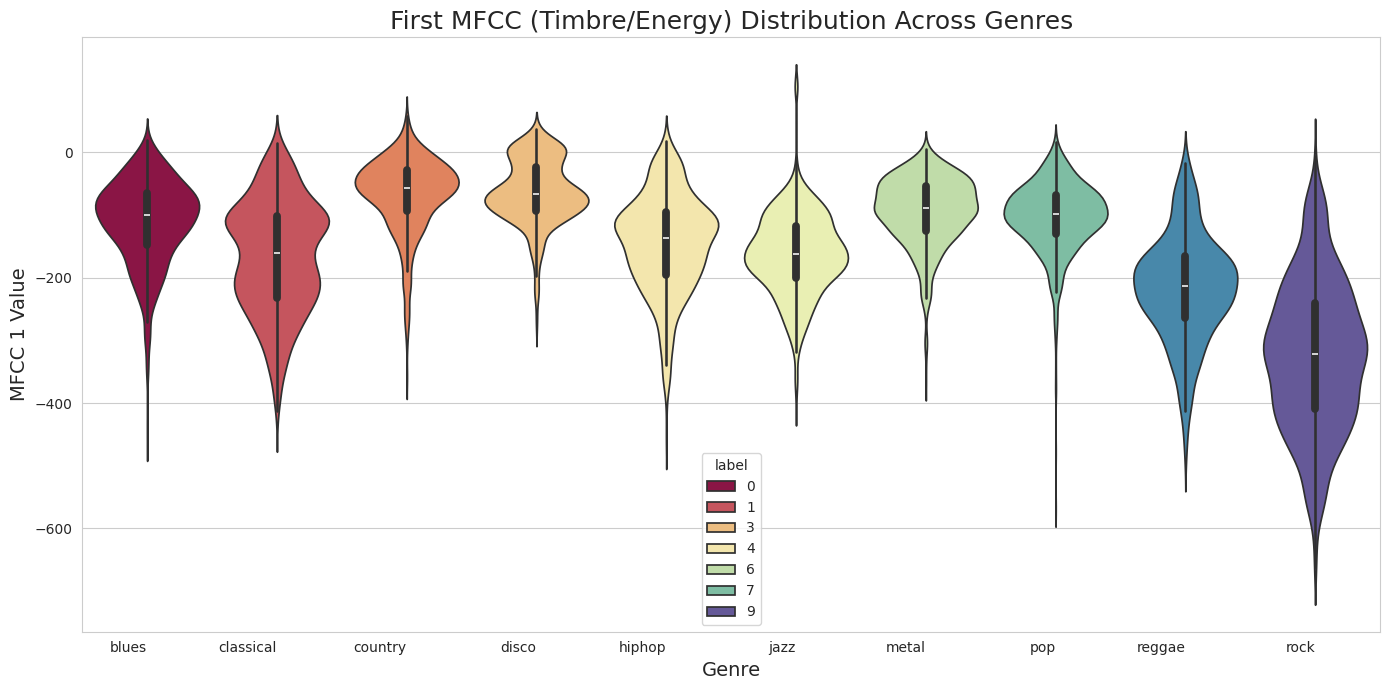

In [11]:
print("\n--- Generating Violin Plot for First MFCC (Column 0) ---")

# Set up the plot style and figure size
plt.figure(figsize=(14, 7))

# Create the violin plot using Seaborn
# x='genre_label': The categorical variable for the x-axis (our genres)
# y='0': The numerical variable for the y-axis (First MFCC coefficient)
# data=features_df: The DataFrame containing the data
violin_ax = sns.violinplot(x='label', y='feature_0', data=features_df, palette='Spectral',hue='label')

# Set the plot title and labels with descriptive names
violin_ax.set_title('First MFCC (Timbre/Energy) Distribution Across Genres', fontsize=18)
violin_ax.set_xlabel('Genre', fontsize=14)
violin_ax.set_ylabel('MFCC 1 Value', fontsize=14)

# Set the x-axis tick labels to be the actual genre names
violin_ax.set_xticklabels(genre_names, rotation=0, ha="right")

# Display the plot
plt.tight_layout()
plt.show()

In [12]:
print("\n Computing correlation matrix : \n")
matrix = features_df.corr()
matrix


 Computing correlation matrix : 



,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,label
feature_0,1.000000,-0.611889,-0.087221,0.042298,-0.078957,0.154607,0.031361,0.257009,0.061883,0.270140,...,0.398164,0.364711,0.377543,0.324497,0.304768,0.331131,0.685916,0.688446,0.590293,-0.418114
feature_1,-0.611889,1.000000,-0.271630,0.061210,-0.153321,-0.061477,-0.242920,-0.159056,-0.286878,-0.177379,...,-0.355124,-0.292459,-0.351402,-0.277570,-0.283376,-0.318110,-0.931581,-0.923649,-0.739812,0.218751
feature_2,-0.087221,-0.271630,1.000000,-0.347756,0.568820,-0.191252,0.482604,-0.253341,0.406256,-0.300110,...,0.024234,-0.014401,0.017814,-0.036968,0.036426,0.045055,0.195017,0.308698,-0.169160,-0.035149
feature_3,0.042298,0.061210,-0.347756,1.000000,-0.362155,0.612625,-0.399182,0.584272,-0.393366,0.477249,...,0.127986,0.078823,0.163775,0.161329,0.139810,0.143684,-0.165138,-0.182078,-0.044189,-0.158718
feature_4,-0.078957,-0.153321,0.568820,-0.362155,1.000000,-0.360503,0.689935,-0.352951,0.605041,-0.393517,...,0.037763,0.034037,0.051149,0.047239,0.069074,0.078868,0.077949,0.137000,-0.184554,0.009753
feature_5,0.154607,-0.061477,-0.191252,0.612625,-0.360503,1.000000,-0.403881,0.768714,-0.378834,0.641925,...,0.238929,0.169529,0.249798,0.209312,0.204274,0.225439,-0.026492,-0.005400,0.020081,-0.232294
feature_6,0.031361,-0.242920,0.482604,-0.399182,0.689935,-0.403881,1.000000,-0.411637,0.712488,-0.370726,...,0.063092,0.071461,0.088743,0.050656,0.076757,0.115401,0.196332,0.235214,-0.040109,0.031371
feature_7,0.257009,-0.159056,-0.253341,0.584272,-0.352951,0.768714,-0.411637,1.000000,-0.352209,0.721220,...,0.290132,0.202760,0.298414,0.248762,0.244922,0.269919,0.088634,0.095688,0.140881,-0.232823
feature_8,0.061883,-0.286878,0.406256,-0.393366,0.605041,-0.378834,0.712488,-0.352209,1.000000,-0.309359,...,0.070993,0.099246,0.120185,0.087716,0.118714,0.146802,0.260491,0.288021,0.052312,0.076276
feature_9,0.270140,-0.177379,-0.300110,0.477249,-0.393517,0.641925,-0.370726,0.721220,-0.309359,1.000000,...,0.302142,0.232955,0.314174,0.245783,0.203808,0.202445,0.146965,0.140994,0.220896,-0.164175


Generating Heatmap of features correlation : 



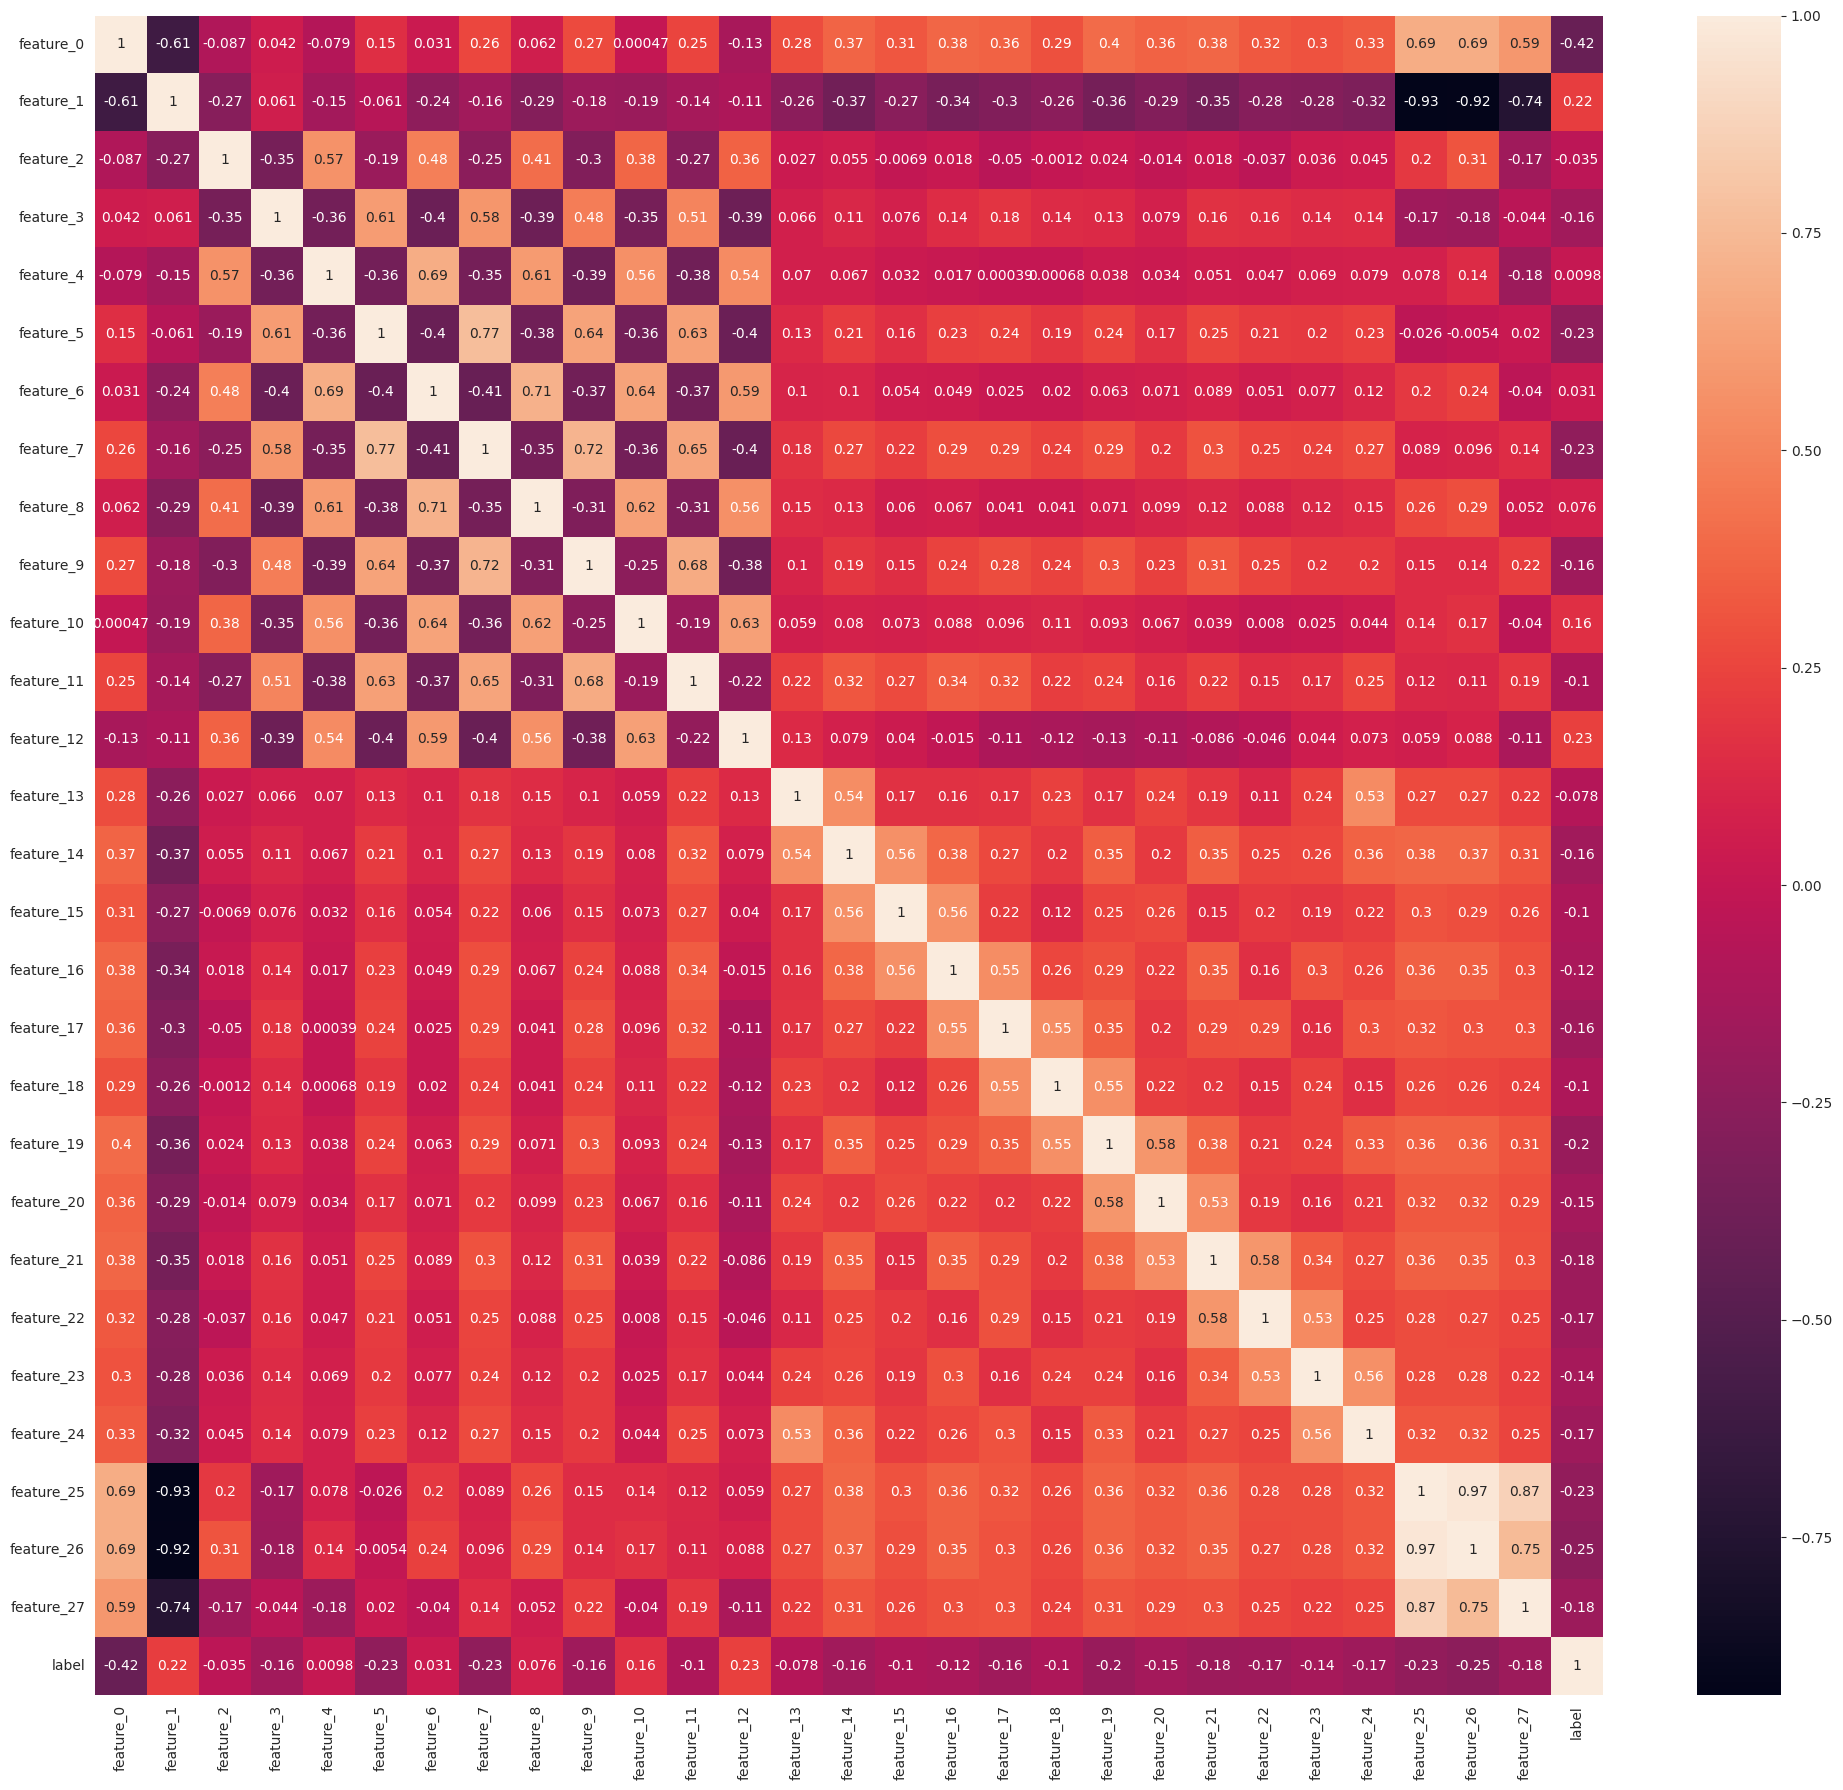

In [14]:
print("Generating Heatmap of features correlation : \n")
plt.figure(figsize=(20,18))
sns.heatmap(matrix, annot=True)
plt.tight_layout()
plt.show()